# Tools

Contents:
- How to Build Tools
  - How Tool Calling Works
  - Building Hand-Crafted Tools
  - Wrapping Tools
  - Using Libraries
- Building Tools for Our Agent
  - Recap — Agent from Previous Lesson
  - Adding Real Tools


## 0. Environment setup

Install dependencies and create LLM wrapper

In [ ]:
!pip install openai

In [3]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()  # reads .env file from project root

MODEL = "gpt-4o-mini"

client = OpenAI()  # picks up OPENAI_API_KEY from env automatically

def call_llm(prompt: str) -> str:
    response = client.responses.create(
        model=MODEL,
        input=prompt,
    )

    return response.output_text

# 1. How to build tools

# 1.1. How tool-calling works

LLMs produce outputs as text; to affect the world (compute, fetch data, mutate state), the agent must call external tools.

In [4]:
import json


def build_initial_prompt(tools_descr: str, user_text: str) -> str:
  system_prompt = f"""
      You are a tool-using assistant.

      You have access to the following tools:
      {tools_descr}

      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {{"type":"tool_call","name":"<tool_name>","arguments":{{...}}}}

      When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
      {{"type":"final","answer":"..."}}
    """
  return f"{system_prompt}\n\nUSER: {user_text}\n"

def process_tool_call(json_model_output, tools_by_name):
    tool_name = json_model_output["name"]
    tool_args = json_model_output["arguments"]
    print(f'Executing tool {tool_name} with args: {tool_args}')

    if tool_name not in tools_by_name:
      raise ValueError("Unknown tool")

    tool_result = tools_by_name[tool_name](**tool_args)

    print(f'Tool result: {tool_result}')

    return tool_result


def run_agent_inner(prompt, tools_by_name):
    # call LLM
    model_output = call_llm(prompt)
    json_model_output = json.loads(model_output)
    print(f"model_output: {model_output}")

    # process tool-call if needed
    if json_model_output["type"] == "tool_call":
        tool_result = process_tool_call(json_model_output, tools_by_name)

        # call LLM with the tool_result
        prompt_with_tool_result = (
            f"{prompt}\n"
            f"ASSISTANT: {model_output}\n"
            f"TOOL_RESULT: {tool_result}\n"
        )
        return run_agent_inner(prompt_with_tool_result, tools_by_name)

    print("\n\n==================Last prompt==================")
    print(prompt)
    print(f"\n\n====Final result: {json_model_output['answer']}===")
    return json_model_output["answer"]



## 1.2. Building hand-crafted tools

In [5]:
def multiply(a, b):
    return a * b

RAW_TOOLS_BY_NAME = {
    'multiply': multiply
}

RAW_TOOLS_DESC = """
        Tool name: multiply
        Description: Multiply two integers
        Arguments:
          - a: integer
          - b: integer
        Returns: integer
"""

def run_agent_with_raw_tools(user_text: str):
    print(f"\n\nUser query: {user_text}\n\n")
    prompt = build_initial_prompt(RAW_TOOLS_DESC, user_text)
    res = run_agent_inner(prompt, RAW_TOOLS_BY_NAME)

In [6]:
run_agent_with_raw_tools("What is 17 multiplied by 23?")




User query: What is 17 multiplied by 23?


model_output: {"type":"tool_call","name":"multiply","arguments":{"a":17,"b":23}}
Executing tool multiply with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type":"final","answer":"391"}


==================Last prompt==================

      You are a tool-using assistant.

      You have access to the following tools:
      
        Tool name: multiply
        Description: Multiply two integers
        Arguments:
          - a: integer
          - b: integer
        Returns: integer


      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"tool_call","name":"<tool_name>","arguments":{...}}

      When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"final","answer":"..."}
    

USER: What is 17 multiplied by 23?

ASSISTANT: {"type":"tool_call","name":"multiply","arguments":{"a":17,"b":23}}
TOOL_RESULT: 391



====F

In [7]:
run_agent_with_raw_tools("What is 17 multiplied by 23 and multiplied by 10?")



User query: What is 17 multiplied by 23 and multiplied by 10?


model_output: {"type":"tool_call","name":"multiply","arguments":{"a":17,"b":23}}
Executing tool multiply with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type":"tool_call","name":"multiply","arguments":{"a":391,"b":10}}
Executing tool multiply with args: {'a': 391, 'b': 10}
Tool result: 3910
model_output: {"type":"final","answer":"17 multiplied by 23 and then multiplied by 10 is 3910."}


==================Last prompt==================

      You are a tool-using assistant.

      You have access to the following tools:
      
        Tool name: multiply
        Description: Multiply two integers
        Arguments:
          - a: integer
          - b: integer
        Returns: integer


      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"tool_call","name":"<tool_name>","arguments":{...}}

      When you want to answer the user, output EXACTLY one 

In [8]:
run_agent_with_raw_tools("What is the capital of Great Britain?")



User query: What is the capital of Great Britain?


model_output: {"type":"final","answer":"The capital of Great Britain is London."}


==================Last prompt==================

      You are a tool-using assistant.

      You have access to the following tools:
      
        Tool name: multiply
        Description: Multiply two integers
        Arguments:
          - a: integer
          - b: integer
        Returns: integer


      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"tool_call","name":"<tool_name>","arguments":{...}}

      When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"final","answer":"..."}
    

USER: What is the capital of Great Britain?



====Final result: The capital of Great Britain is London.===


Problems:

🔴 how to add lots of tools in the same format

🔴 what if something changes in the tool


## 1.3. Wrapping tools

### 1.3.1. Using class for unification

In [9]:

from typing import Callable, Any, List, Tuple

class Tool:
    def __init__(
        self,
        name: str,
        description: str,
        func: Callable[..., Any],
        arguments: List[Tuple[str, str]],
        outputs: str,
    ):
        self.name = name
        self.description = description
        self.func = func
        self.arguments = arguments
        self.outputs = outputs

    def to_string(self) -> str:
        args_str = ", ".join([f"{n}: {t}" for n, t in self.arguments])
        return (
            f"Tool Name: {self.name},"
            f" Description: {self.description},"
            f" Arguments: {args_str},"
            f" Outputs: {self.outputs}"
        )

    def __call__(self, *args, **kwargs):
        return self.func(*args, **kwargs)


In [10]:

def multiply(a, b):
    return a * b

class_multiply = Tool(
    "multiplier",
    "Multiply two integers",
    multiply,
    [("a", "int"), ("b", "int")],
    "int",
)

class_multiply.to_string()

'Tool Name: multiplier, Description: Multiply two integers, Arguments: a: int, b: int, Outputs: int'

Problems:

🟢 how to add lots of tools in the same format

🔴 what if something changes in the tool


### 1.3.2. "Decorating" tools

Decorator:
- Reads the function signature
- Extracts the argument types
- Extracts the return type
- Uses the docstring as the description


In [12]:
import inspect

def wrap_tool(func: Callable[..., Any]) -> Tool:
    sig = inspect.signature(func)

    # args
    arguments = []
    for p in sig.parameters.values():
        ann = p.annotation
        if ann is inspect._empty:
            ann_name = "Any"
        else:
            ann_name = getattr(ann, "__name__", str(ann))

        arguments.append((p.name, ann_name))

    # return type
    ret = sig.return_annotation
    if ret is inspect._empty:
        outputs = "Any"
    else:
        outputs = getattr(ret, "__name__", str(ret))

    description = (func.__doc__ or "No description provided").strip()
    name = func.__name__

    return Tool(name, description, func, arguments, outputs)


In [13]:
@wrap_tool
def multiply_tool(a: int, b: int) -> int:
    """Multiply two integers and return the result."""
    return a * b

multiply_tool.to_string()

'Tool Name: multiply_tool, Description: Multiply two integers and return the result., Arguments: a: int, b: int, Outputs: int'

Problems:

🟢 how to add lots of tools in the same format

🟢 what if something changes in the tool


### 1.3.3. All together

In [14]:
@wrap_tool
def multiply_tool(a: int, b: int) -> int:
    """Multiply two integers and return the result."""
    return a * b

NICE_TOOLS_BY_NAME = {
    'multiply_tool': multiply_tool
}

NICE_TOOLS_DESC = "\n".join([t.to_string() for t in NICE_TOOLS_BY_NAME.values()])

def run_agent_with_nice_tools(user_text: str):
    print(f"\n\nUser query: {user_text}\n\n")
    prompt = build_initial_prompt(NICE_TOOLS_DESC, user_text)
    res = run_agent_inner(prompt, NICE_TOOLS_BY_NAME)

In [15]:
run_agent_with_nice_tools("What is 17 multiplied by 23?")



User query: What is 17 multiplied by 23?


model_output: {"type":"tool_call","name":"multiply_tool","arguments":{"a":17,"b":23}}
Executing tool multiply_tool with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type":"final","answer":"391"}


==================Last prompt==================

      You are a tool-using assistant.

      You have access to the following tools:
      Tool Name: multiply_tool, Description: Multiply two integers and return the result., Arguments: a: int, b: int, Outputs: int

      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"tool_call","name":"<tool_name>","arguments":{...}}

      When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"final","answer":"..."}
    

USER: What is 17 multiplied by 23?

ASSISTANT: {"type":"tool_call","name":"multiply_tool","arguments":{"a":17,"b":23}}
TOOL_RESULT: 391



====Final result: 391===


## 1.4. Using libraries

So far we built tool usage **from scratch**:
- defined tool format
- wrote parser
- handled tool execution manually

Libraries like LangChain/LangGraph automate this process:
- tool registration
- tool calling protocol
- agent loop
- message formatting

We will rebuild the same example using LangChain.

In [ ]:
!pip install langgraph langchain langchain-openai

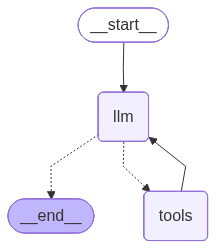

In [18]:
from typing import Annotated, TypedDict, List

from langchain.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b


# Agent state with a reducer: messages will be appended, not overwritten
# Reducer --- answers the question: "how to change the old state given the result of node output"
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]


# Bind tools to the model so it can produce tool calls
llm = ChatOpenAI(model=MODEL, temperature=0).bind_tools([multiply])


# LLM node: produce either tool calls or a final answer
def llm_node(state: AgentState) -> dict:
    response = llm.invoke(state["messages"])
    # Return only the new message; the reducer will append it to state["messages"]
    return {"messages": [response]}


# Tool node: executes tool calls and returns ToolMessage(s)
tools_node = ToolNode([multiply])


# Build the graph
graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.add_node("tools", tools_node)

graph.set_entry_point("llm")

# Route to tools if the last AI message contains tool calls; otherwise end
graph.add_conditional_edges("llm", tools_condition, {"tools": "tools", END: END})

# After tools run, go back to the LLM so it can use tool results
graph.add_edge("tools", "llm")

app = graph.compile()
app

In [24]:
result = app.invoke({
    "messages": [
        SystemMessage(content="You are a tool-using assistant. Always try to use provided tools."),
        HumanMessage(content="What is 17 multiplied by 23?")
    ]
})
print(result["messages"][-1].content)

17 multiplied by 23 is 391.


In [37]:
from IPython.display import display, HTML
import html

def pretty_print_dialogue_and_tools(result_dict, show_final_prompt=True, compact=True, max_chars=220):
    messages = result_dict.get("messages", [])

    def msg_kind(msg):
        name = type(msg).__name__.lower()
        if "human" in name:
            return "Human"
        if "system" in name:
            return "System"
        if "tool" in name:
            return "Tool"
        return "AI"

    def truncate(text, n=max_chars):
        text = text or ""
        return text if len(text) <= n else text[:n] + " …"

    def render_message(msg, idx):
        kind = msg_kind(msg)
        content = html.escape(getattr(msg, "content", "") or "")
        content = truncate(content)

        tool_calls = getattr(msg, "tool_calls", None)
        tool_call_id = getattr(msg, "tool_call_id", None)

        parts = [
            f'<div class="row {kind.lower()}">',
            f'<span class="badge">{kind}</span>',
            f'<span class="msg">{content if content.strip() else "<i>(empty)</i>"}</span>',
        ]

        if tool_calls:
            calls = []
            for call in tool_calls:
                name = html.escape(str(call.get("name", "")))
                args = html.escape(str(call.get("args", {})))
                calls.append(f'<span class="toolcall"><b>{name}</b> {args}</span>')
            parts.append(f'<div class="sub">{" | ".join(calls)}</div>')

        if tool_call_id:
            parts.append(f'<div class="sub">tool_call_id: {html.escape(str(tool_call_id))}</div>')

        parts.append("</div>")
        return "\n".join(parts)

    css = """
    <style>
      .wrap { font-family: Arial, sans-serif; line-height: 1.35; }
      .title { font-size: 16px; font-weight: 700; margin: 0 0 10px 0; }
      .section { margin: 10px 0 14px 0; }
      .section h4 { margin: 0 0 8px 0; font-size: 13px; color: #374151; }
      .row {
        display: flex; gap: 10px; align-items: flex-start;
        padding: 8px 10px; margin: 6px 0; border-radius: 8px;
        border: 1px solid #e5e7eb; background: #fff;
      }
      .badge {
        min-width: 54px; text-align: center; font-size: 12px; font-weight: 700;
        border-radius: 999px; padding: 2px 8px; color: #fff;
      }
      .human .badge { background: #2563eb; }
      .ai .badge { background: #16a34a; }
      .tool .badge { background: #7c3aed; }
      .system .badge { background: #f59e0b; }
      .msg { white-space: pre-wrap; flex: 1; }
      .sub { margin-top: 4px; font-size: 12px; color: #6b7280; }
      .toolcall { display: inline-block; margin-right: 10px; }
      .prompt {
        white-space: pre-wrap; background: #f9fafb; border: 1px solid #e5e7eb;
        border-radius: 8px; padding: 10px; font-family: Consolas, monospace;
        font-size: 12px;
      }
    </style>
    """

    html_parts = [css, '<div class="wrap">', '<div class="title">Dialogue Trace</div>']

    if show_final_prompt and messages:
        prompt_messages = messages[:-1] if len(messages) > 1 else messages
        prompt_text = []
        for m in prompt_messages:
            prompt_text.append(f"{type(m).__name__}: {getattr(m, 'content', '')}")
        prompt_text = "\n\n".join(prompt_text)

        html_parts += [
            '<div class="section">',
            '<h4>Final prompt</h4>',
            f'<div class="prompt">{html.escape(prompt_text)}</div>',
            '</div>',
        ]

    html_parts.append('<div class="section"><h4>Messages</h4>')
    for i, msg in enumerate(messages, start=1):
        html_parts.append(render_message(msg, i))
    html_parts.append("</div></div>")

    display(HTML("".join(html_parts)))

pretty_print_dialogue_and_tools(result, show_final_prompt=True, compact=True)


In [38]:
for step in app.stream(
    {
        "messages": [
          SystemMessage(content="You are a tool-using assistant. Always try to use provided tools."),
          HumanMessage(content="What is 17 multiplied by 23?")
        ]
    },
    stream_mode="values",
):
    last = step["messages"][-1]

    print("NODE OUTPUT:")
    print(type(last).__name__)

    if hasattr(last, "content"):
        print("Content:", last.content)

    if hasattr(last, "tool_calls") and last.tool_calls:
        print("Tool calls:", last.tool_calls)

    print("==========")

NODE OUTPUT:
HumanMessage
Content: What is 17 multiplied by 23?
NODE OUTPUT:
AIMessage
Content: 
Tool calls: [{'name': 'multiply', 'args': {'a': 17, 'b': 23}, 'id': 'call_LpXcjL97v9W4VV1n5mLvqsdP', 'type': 'tool_call'}]
NODE OUTPUT:
ToolMessage
Content: 391
NODE OUTPUT:
AIMessage
Content: 17 multiplied by 23 is 391.


# 2. Building tools for our agent

## 2.1. Recap - agent from previous lesson


In [39]:
!pip install -q langchain langgraph langchain-openai

In [49]:
from typing import List, TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph import StateGraph, END


SYSTEM_PROMPT = """
  You are a virtual airline assistant.
  IMPORTANT: In this lesson you have NO tools, NO database access, NO RAG.
  You must be transparent about limitations:
  - You cannot look up flights, reservations, user profiles, baggage on a specific reservation, insurance status, or real-time flight status.
  - You can only: explain the policy, ask clarifying questions, and outline what info is needed to proceed.
  - Do NOT invent flight details, reservation details, membership level, prices, or statuses.
  - Do NOT provide subjective recommendations.
"""

llm = ChatOpenAI(model=MODEL)

class AgentState(TypedDict):
    messages: List[BaseMessage]


def llm_node(state: AgentState) -> AgentState:
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm.invoke(msgs)
    return {"messages": state["messages"] + [resp]}


graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.set_entry_point("llm")
graph.add_edge("llm", END)

app = graph.compile()

# --- tiny helper to talk to the agent ---
def ask(user_text: str, app) -> str:
    print("\n🟣 USER QUERY")
    print(">" * 50)
    print(user_text)

    state = {"messages": [HumanMessage(content=user_text)]}
    out = app.invoke(state)
    answer = out["messages"][-1].content

    if "pretty_print_dialogue_and_tools" in globals():
        pretty_print_dialogue_and_tools(out, show_final_prompt=True, compact=True)
    else:
        print("\n🟢 AGENT RESPONSE")
        print("<" * 50)
        print(answer)
        print()

    return answer

ask('Who are you?', app)


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Who are you?


'I am a virtual airline assistant here to help you with questions about airline policies, procedures, and general information. However, I cannot access any specific flight details, reservations, or user profiles. How may I assist you today?'

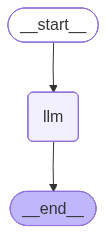

In [50]:
app

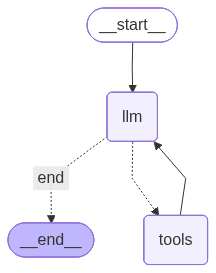

In [51]:
import json
from typing import List, TypedDict, Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

# ----------------------------
# 0) Tiny in-memory "database"
# ----------------------------
DATABASE = {
    "flights": {
        # flight_key -> flight record
        "AY001_2026-02-22": {
            "flight_key": "AY001_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "09:30",
            "seats": 3,
            "price": 120,
        },
        "AY101_2026-02-22": {
            "flight_key": "AY101_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "16:10",
            "seats": 1,
            "price": 155,
        },
    },
    "bookings": {
        # booking_id -> booking record
        "BKG-123": {
            "booking_id": "BKG-123",
            "flight_key": "AY001_2026-02-22",
            "passenger_name": "Jane Doe",
            "status": "confirmed",
        }
    },
}


# -----------------------
# 1) Tools
# -----------------------
@tool
def get_booking(booking_id: str) -> str:
    """Retrieve a booking by ID."""
    booking_record = DATABASE["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": f"Booking {booking_id} not found"}, ensure_ascii=False)

    flight_record = DATABASE["flights"].get(booking_record["flight_key"], {})
    return json.dumps(
        {"booking_id": booking_id, **booking_record, "flight": flight_record},
        ensure_ascii=False,
    )


@tool
def search_flights(origin: str, destination: str, date: str) -> str:
    """Search available flights."""
    matching_flights = [
        flight
        for flight in DATABASE["flights"].values()
        if flight["from"] == origin
        and flight["to"] == destination
        and flight["date"] == date
        and flight["seats"] > 0
    ]
    return json.dumps(
        sorted(matching_flights, key=lambda f: f["time"]),
        ensure_ascii=False,
    )


@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel a booking."""
    booking_record = DATABASE["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": "Booking not found"}, ensure_ascii=False)

    flight_record = DATABASE["flights"].get(booking_record["flight_key"])
    booking_record["status"] = "cancelled"

    if flight_record:
        flight_record["seats"] += 1

    refund_amount = flight_record["price"] if flight_record else 0
    return json.dumps({"success": True, "refund": refund_amount}, ensure_ascii=False)


TOOLS = [get_booking, search_flights, cancel_booking]


# -----------------------
# 2) Prompt (system)
# -----------------------
POLICIES: List[str] = [
    "Use tools when they are needed to answer accurately",
    "Never invent booking details, flight details, prices, or statuses",
    "If information is insufficient, ask clarifying questions.",
    "Request confirmation before any booking cancellation. Ask explicitly and wait for user confirmation",
    "Retrieve the current booking before proposing changes",
]

SYSTEM_PROMPT = (
    "You are a virtual airline assistant.\n"
    "POLICIES:\n"
    + "\n".join(f"* {p}" for p in POLICIES)
).strip()


# -----------------------
# 3) Agent state with a reducer: messages will be appended, not overwritten
# -----------------------
class AgentStateRed(TypedDict):
    # messages: List[BaseMessage]
    messages: Annotated[List[BaseMessage], add_messages]


# -----------------------
# 4) LLM node
# -----------------------
# llm = ChatOpenAI(model=MODEL)
llm_with_tools = ChatOpenAI(model=MODEL).bind_tools(TOOLS)


# same
def llm_with_tools_node(state: AgentStateRed) -> AgentStateRed:
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm_with_tools.invoke(msgs)
    return {"messages": [resp]}


# ----------------------------
# 5) Router: decide whether to call tools
# ----------------------------
def route_after_llm(state: AgentStateRed) -> Literal["tools", "end"]:
    last = state["messages"][-1]
    # If the model requested tool calls, send to ToolNode; else finish.
    has_tool_calls = getattr(last, "tool_calls", None)
    return "tools" if has_tool_calls else "end"


# ----------------------------
# 6) Build the graph
# ----------------------------
graph_with_tools = StateGraph(AgentStateRed)

graph_with_tools.add_node("llm", llm_with_tools_node)
graph_with_tools.add_node("tools", ToolNode(TOOLS))

graph_with_tools.set_entry_point("llm")

# If LLM asked for tools -> tools; otherwise -> END
graph_with_tools.add_conditional_edges(
    "llm",
    route_after_llm,
    {"tools": "tools", "end": END},
)

# After tools run, go back to LLM (so it can interpret tool results and answer / ask next question)
graph_with_tools.add_edge("tools", "llm")

app_with_tools = graph_with_tools.compile()

app_with_tools

In [52]:
# --- demo ---
ask("Find flights from HEL to AMS on 2026-02-22", app_with_tools)
ask("What's in booking BKG-123?", app_with_tools)
ask("Cancel booking BKG-123", app_with_tools)  # should ask for confirmation per policy (ideally)



🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Find flights from HEL to AMS on 2026-02-22



🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
What's in booking BKG-123?



🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Cancel booking BKG-123


'Your booking BKG-123 is confirmed for the flight from Helsinki (HEL) to Amsterdam (AMS) on February 22, 2026, at 09:30. \n\nBefore I proceed with the cancellation, could you please confirm that you would like to cancel this booking?'

In [53]:
class Chat:
    def __init__(self, app):
        self.state = {"messages": []}
        self.app = app

    def ask(self, user_text: str) -> str:
        print("\n🟣 USER QUERY")
        print(">" * 50)
        print(user_text)

        self.state["messages"].append(HumanMessage(content=user_text))
        out = self.app.invoke(self.state)
        self.state = out
        answer = out["messages"][-1].content


        print("\n🟢 AGENT RESPONSE")
        print("<" * 50)
        print(answer)
        print()


chat = Chat(app_with_tools)
print(chat.ask("Cancel booking BKG-123"))



🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Cancel booking BKG-123

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Your booking (BKG-123) is confirmed for flight AY001 from Helsinki (HEL) to Amsterdam (AMS) on February 22, 2026, at 09:30. 

Please confirm if you would like to proceed with the cancellation of this booking.

None


In [54]:
chat.ask("I confirm the cancellation of booking BKG-123")


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
I confirm the cancellation of booking BKG-123

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Booking BKG-123 has been successfully canceled, and a refund of $120 will be processed. If you need any further assistance or wish to book a new flight, please let me know!

